# Bayesian Linear Regression

A simple toy example using bayesian linear regression.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from pai import BLR

mpl.rc_file_defaults()

## Toy Data

In [2]:
rng = np.random.default_rng(42)

x_base = np.linspace(-10, 10, 100).reshape((100, 1))
x = rng.uniform(-10, 10, size=(100, 1))
y = x + rng.normal(size=(100, 1)) + 2

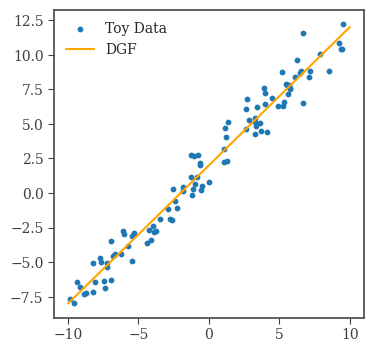

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(x, y, label="Toy Data", s=10)
ax.plot(x_base, x_base + 2, label="DGF", color="orange")
ax.legend()

plt.show()

## Fit BLR

In [4]:
blr = BLR(alpha=1.0, sigma_n=1.0)
blr = blr.fit(x, y)

pred_mu, pred_cov = blr.predict(x_base)

In [9]:
np.diag(pred_cov)

array([1.04186814, 1.04055541, 1.0392702 , 1.03801252, 1.03678235,
       1.03557971, 1.03440459, 1.03325699, 1.03213692, 1.03104436,
       1.02997933, 1.02894182, 1.02793183, 1.02694936, 1.02599441,
       1.02506698, 1.02416708, 1.0232947 , 1.02244984, 1.0216325 ,
       1.02084268, 1.02008038, 1.01934561, 1.01863835, 1.01795862,
       1.01730641, 1.01668172, 1.01608456, 1.01551491, 1.01497279,
       1.01445818, 1.0139711 , 1.01351154, 1.01307951, 1.01267499,
       1.012298  , 1.01194852, 1.01162657, 1.01133214, 1.01106523,
       1.01082585, 1.01061398, 1.01042964, 1.01027282, 1.01014352,
       1.01004174, 1.00996748, 1.00992074, 1.00990153, 1.00990984,
       1.00994567, 1.01000902, 1.01009989, 1.01021828, 1.0103642 ,
       1.01053764, 1.01073859, 1.01096707, 1.01122308, 1.0115066 ,
       1.01181764, 1.01215621, 1.0125223 , 1.01291591, 1.01333704,
       1.01378569, 1.01426187, 1.01476556, 1.01529678, 1.01585552,
       1.01644178, 1.01705556, 1.01769686, 1.01836569, 1.01906

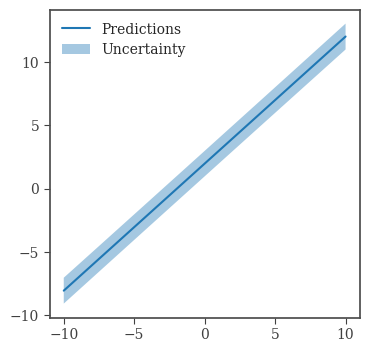

In [19]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(x_base, pred_mu, label=f"Predictions")

std = np.diag(pred_cov) ** 0.5
ax.fill_between(x_base.ravel(), pred_mu - std, pred_mu + std, label="Uncertainty", alpha=0.4)

ax.legend()

plt.show()